# Rice Leaf Classification — SVM

Supervised image classification: จำแนกโรคใบข้าว 4 โรคและใบปกติ เพื่อช่วยคัดกรองภาพเบื้องต้นและศึกษาความแตกต่างระหว่างคลาส ไม่ยืนยันโรคในแปลง

คลาส: Rice Blast (Leaf Blast เท่านั้น), Bacterial Leaf Blight, Sheath Blight, Brown Spot, Healthy Rice Leaf

ข้อมูลมาจาก [loki4514](https://www.kaggle.com/datasets/loki4514/rice-leaf-diseases-detection) (ประกาศ Apache 2.0) และ [alamshihab075](https://www.kaggle.com/datasets/alamshihab075/rice-leaf-disease-an-images-dataset) (ประกาศ MIT). ดูรายละเอียดการอ้างอิงและข้อจำกัดใน DATASET.md

Notebook รันตามลำดับเพื่อทบทวนโมเดลที่ฝึกจริง เปิด RETRAIN เฉพาะเมื่อต้องการฝึกซ้ำ

In [1]:
from pathlib import Path
import sys,json
import numpy as np,pandas as pd
from IPython.display import display,Markdown,Image
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix
ROOT=Path.cwd().resolve()
if not (ROOT/'rice_leaf_app').is_dir():ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
from rice_leaf_app.cnn_config import CLASSES,EXAMPLES,ARTIFACTS
P=ROOT/'experiments/cnn5'
frame=pd.read_csv(P/'manifest.csv')
display(pd.DataFrame([{'label':k,'English':v[0],'Thai':v[1]} for k,v in CLASSES.items()]))
display(pd.crosstab(frame.label,frame.cnn_split))
display(pd.read_csv(ARTIFACTS/'class_counts.csv'))

,label,English,Thai
0,rice_blast,Rice Blast,โรคไหม้
1,bacterial_leaf_blight,Bacterial Leaf Blight,โรคขอบใบแห้ง
2,sheath_blight,Sheath Blight,โรคกาบใบแห้ง
3,brown_spot,Brown Spot,โรคใบจุดสีน้ำตาล
4,healthy,Healthy Rice Leaf,ใบข้าวปกติ


cnn_split,fit,test,validation
label,,,
bacterial_leaf_blight,1182,318,195
brown_spot,1229,349,207
healthy,1952,603,324
rice_blast,2235,605,377
sheath_blight,1588,353,265


,label,raw_train,raw_test,used_train,validation,used_test
0,rice_blast,4620,967,2235,377,605
1,bacterial_leaf_blight,1386,376,1182,195,318
2,sheath_blight,1853,641,1588,265,353
3,brown_spot,1480,380,1229,207,349
4,healthy,3836,994,1952,324,603


## สำรวจ เตรียม และแบ่งข้อมูล

เก็บภาพต้นทาง 5 คลาส 16,533 ไฟล์ แยก train/test ตามโฟลเดอร์ ไม่ใช้ Rice_Leaf_AUG หลังคัดภาพเสีย/ซ้ำ/เสี่ยงรั่ว ใช้ fit 8,186, validation 1,368, test 2,228 ภาพ

แก้ EXIF orientation และวางภาพโปร่งใสบนพื้นขาว ตรวจ decoded RGB hash และกลุ่มภาพคล้ายจาก pHash/RGB หลังหมุน/พลิก เก็บ manifest ที่ระบุ path, label, hash และ split เพื่อทำซ้ำ validation ประมาณ 14.3% ด้วย StratifiedGroupKFold 7 folds seed 42 ไม่มีการใช้ test ฝึกหรือจูนในรอบนี้

กลุ่มความคล้ายไม่ใช่รหัสใบจริง ชุด test เดิมเคยรายงานผลในงานทดลองก่อน จึงไม่ใช่ชุดอิสระใหม่

All dataset paths exist; similarity groups do not cross splits


,label,status,images
0,bacterial_leaf_blight,excluded,58
1,bacterial_leaf_blight,included,1704
2,brown_spot,excluded,31
3,brown_spot,included,1829
4,healthy,excluded,1882
5,healthy,included,2948
6,leaf_blast,excluded,2163
7,leaf_blast,included,3424
8,sheath_blight,excluded,288
9,sheath_blight,included,2206


Rice Blast

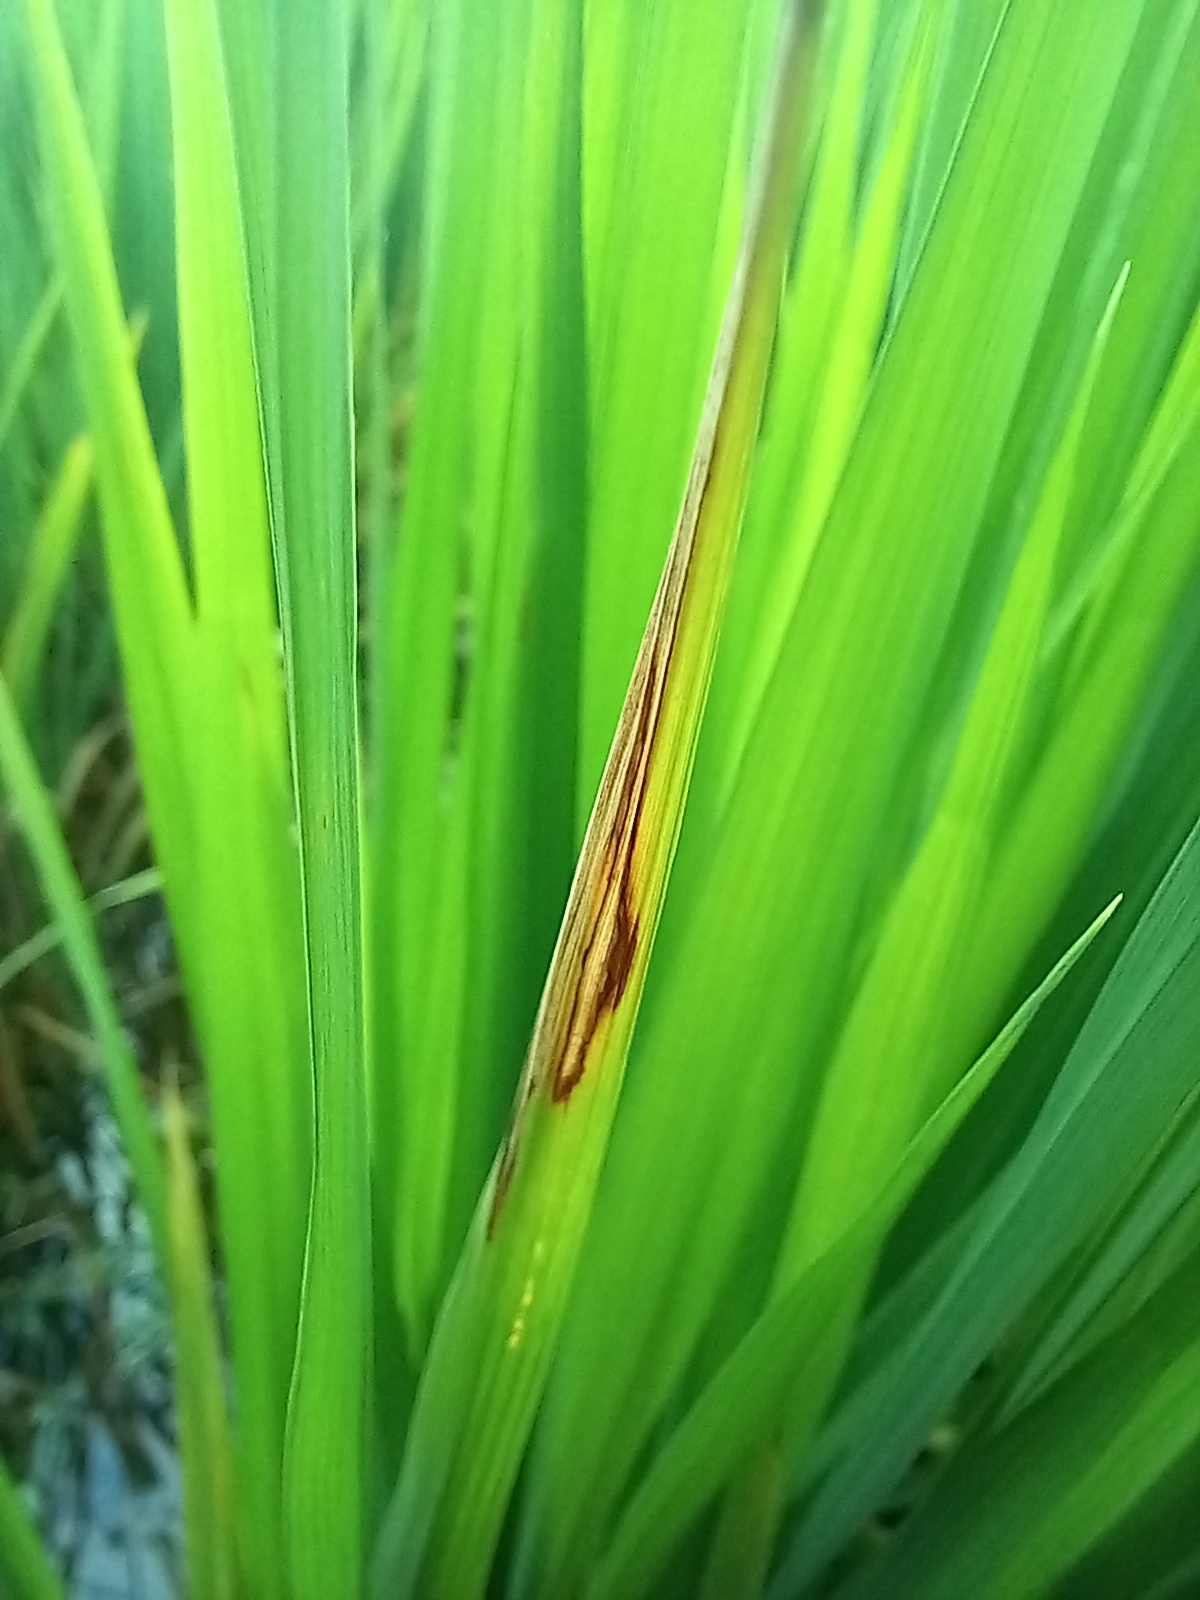

Bacterial Leaf Blight

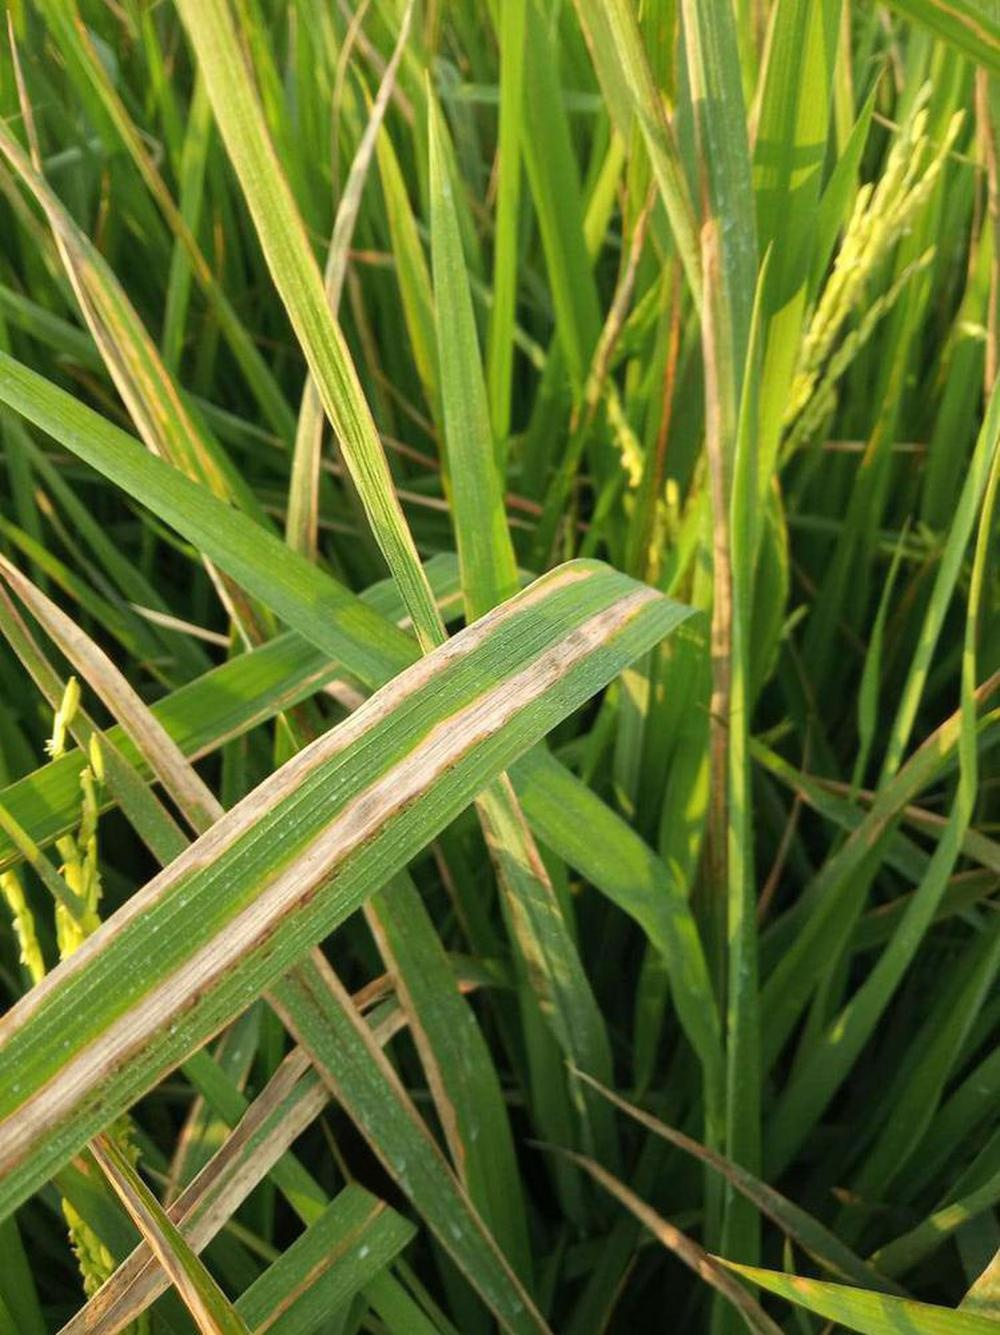

Sheath Blight

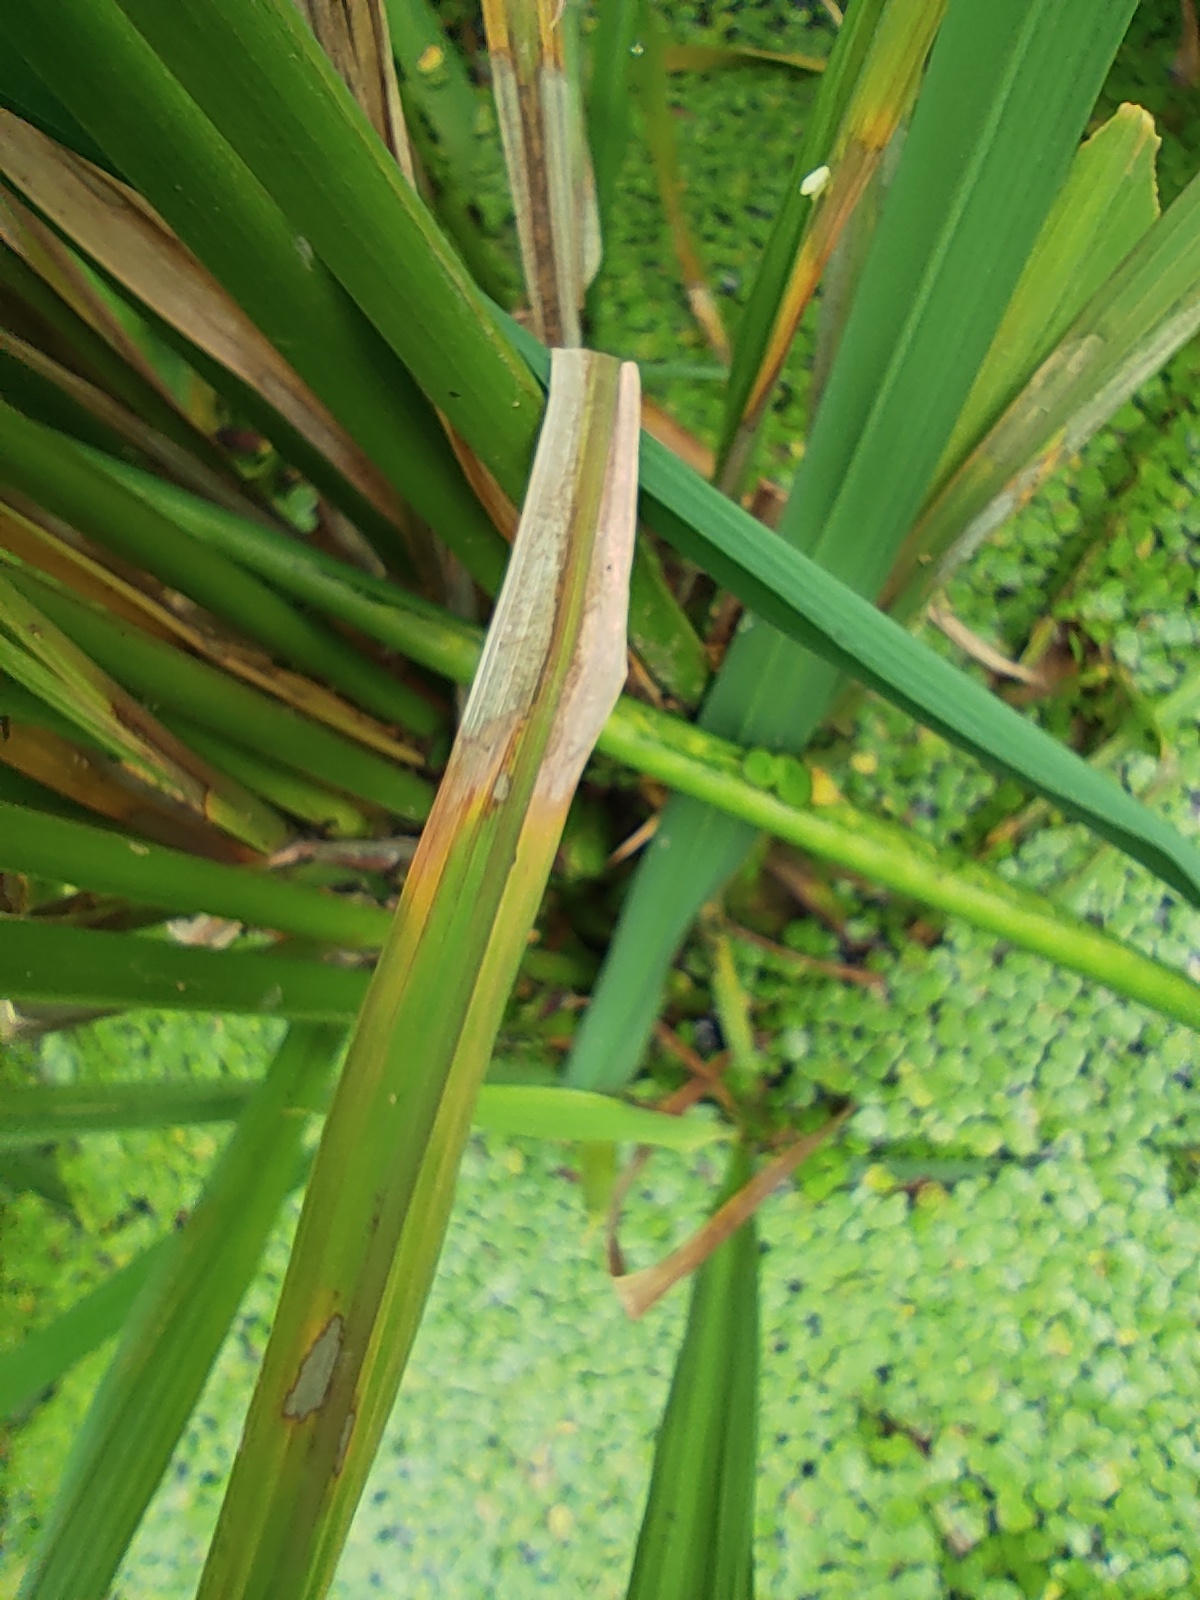

Brown Spot

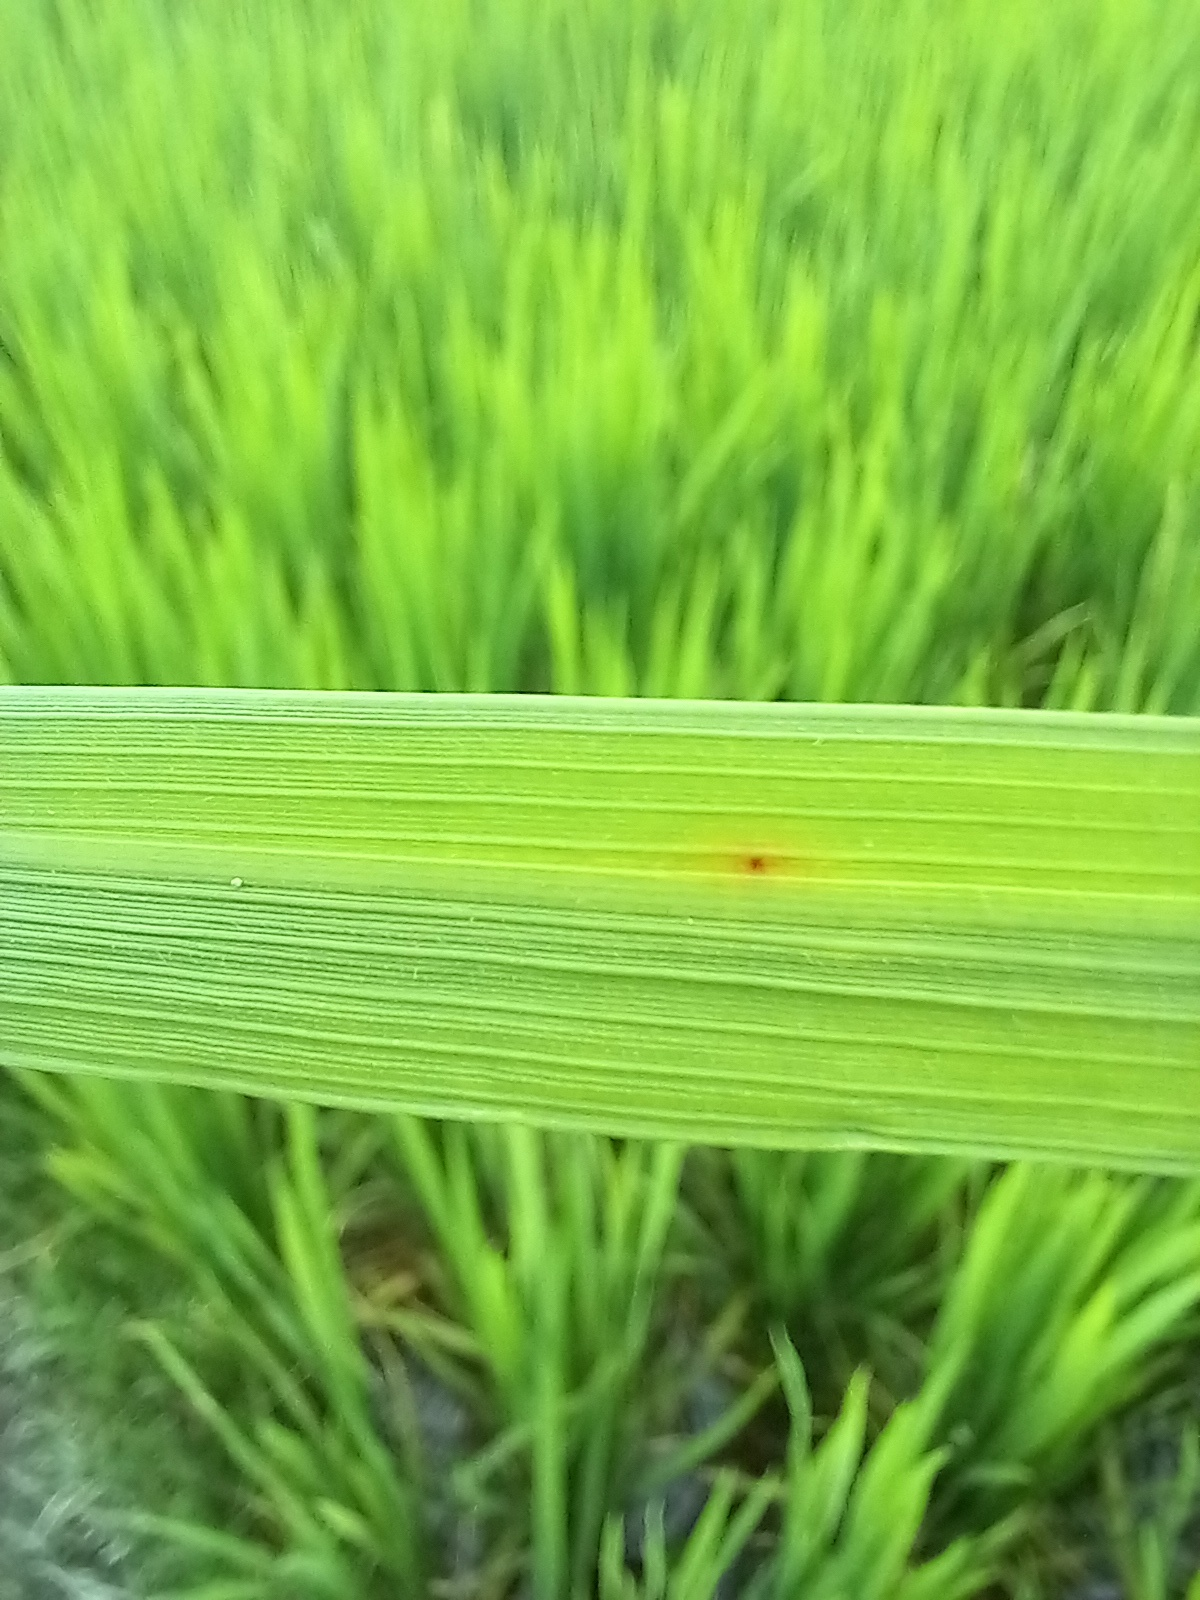

Healthy Rice Leaf

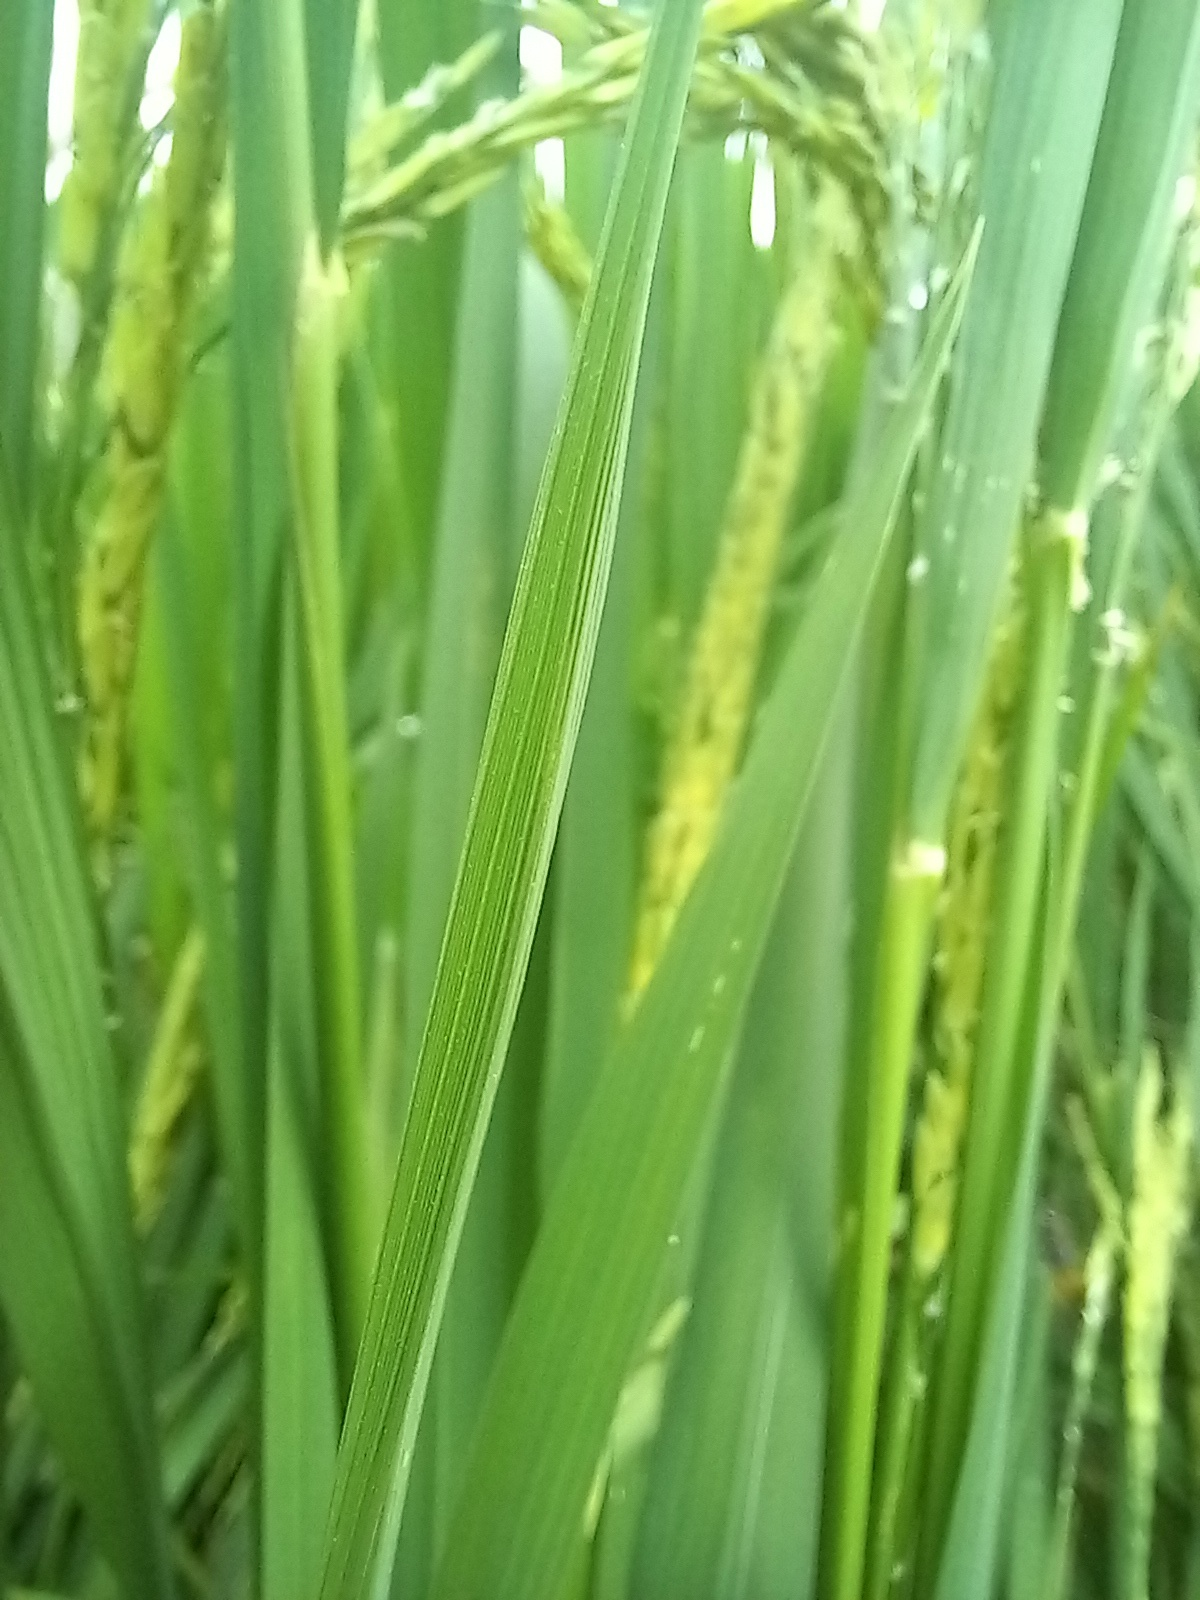

In [2]:
for a,b in [('fit','validation'),('fit','test'),('validation','test')]:
    assert not set(frame.loc[frame.cnn_split.eq(a),'similarity_group']) & set(frame.loc[frame.cnn_split.eq(b),'similarity_group'])
assert all((ROOT/p).is_file() for p in frame.path)
print('All dataset paths exist; similarity groups do not cross splits')
audit=pd.read_csv(ROOT/'data_audit/dataset_manifest.csv')
display(audit.groupby(['label','status']).size().rename('images').reset_index())
for label in CLASSES:
    display(Markdown(CLASSES[label][0]));display(Image(filename=str(EXAMPLES/f'{label}.jpg'),width=180))

## สกัดฟีเจอร์และฝึก SVM

SVM เป็น baseline สำหรับตรวจว่า CNN ให้ประโยชน์เพิ่มจากฟีเจอร์สี/เนื้อสัมผัสหรือไม่ RGB 128×128 LANCZOS, HSV histogram ทั้งภาพและ 2×2, RGB mean/std + gradient histogram รวม 404 มิติ

StandardScaler + RBF SVC, class_weight=balanced, gamma=scale. ลอง C=1 และ 10 แล้วเลือกด้วย validation macro F1 ได้ C=10. probability=True, seed 42; scaler อยู่ใน pipeline ที่บันทึก ไม่ใช้ test ปรับพารามิเตอร์

โค้ด train/evaluation ครบใน experiments/svm/train.py และฟีเจอร์อยู่ rice_leaf_app/preprocessing.py ไม่ใช้ cache จากการทดลองที่ลบไป

In [3]:
RETRAIN=False
if RETRAIN:
    import subprocess
    subprocess.run([sys.executable,str(ROOT/'experiments/svm/train.py')],cwd=ROOT.parent,check=True)
import joblib
pack=joblib.load(ROOT/'rice_leaf_app/models/rice_svm.joblib')
display(pd.DataFrame(pack['candidates']))
print(pack['model'])
from rice_leaf_app.preprocessing import image_to_features
print('Feature dimensions:',image_to_features(EXAMPLES/'healthy.jpg').shape)
print('Saved pipeline includes StandardScaler and trained SVC')

,C,validation_macro_f1
0,1.0,0.886426
1,10.0,0.942809


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(C=10.0, cache_size=512, class_weight='balanced',
                     probability=True, random_state=42))])


Feature dimensions: (404,)
Saved pipeline includes StandardScaler and trained SVC


## ประเมิน test และความหมาย

คำนวณคะแนนใหม่จากผลทำนายที่โมเดลรันจริงและตรวจเทียบกับรายงาน Accuracy คือสัดส่วนถูก, macro F1 เฉลี่ยทุกคลาสเท่ากัน, weighted F1 ถ่วงตามจำนวนภาพ; recall บอกสัดส่วนภาพจริงของคลาสที่หาเจอ

CNN ตอบไม่แน่ใจเมื่อคะแนนต่ำกว่า 0.50 (เลือกจาก validation) และนับเป็นจำแนกไม่ถูกใน accuracy/recall หลัก SVM baseline เลือกคะแนนสูงสุด ไม่มีเกณฑ์ปฏิเสธ

In [4]:
pred=pd.read_csv(ROOT/'experiments/svm/predictions.csv')
metrics=json.loads((ROOT/'experiments/svm/metrics.json').read_text(encoding='utf-8'))
labels=list(CLASSES)
assert abs(accuracy_score(pred.label,pred.predicted)-metrics['accuracy'])<1e-12
assert abs(f1_score(pred.label,pred.predicted,labels=labels,average='macro')-metrics['macro_f1'])<1e-12
display(pd.Series({k:metrics[k] for k in ['accuracy','macro_f1','minimum_recall','minimum_recall_class']}))
display(pd.DataFrame(classification_report(pred.label,pred.predicted,labels=labels,output_dict=True,zero_division=0)).T)
display(pd.DataFrame(confusion_matrix(pred.label,pred.predicted,labels=labels+['uncertain'])[:5],index=labels,columns=labels+['uncertain']))
display(pd.read_csv(ARTIFACTS/'model_comparison.csv'))

accuracy                     0.890036
macro_f1                     0.903289
minimum_recall               0.824363
minimum_recall_class    sheath_blight
dtype: object

,precision,recall,f1-score,support
rice_blast,0.780089,0.867769,0.821596,605.000000
bacterial_leaf_blight,0.996865,1.000000,0.998430,318.000000
sheath_blight,0.973244,0.824363,0.892638,353.000000
brown_spot,0.947531,0.879656,0.912333,349.000000
healthy,0.884176,0.898839,0.891447,603.000000
accuracy,0.890036,0.890036,0.890036,0.890036
macro avg,0.916381,0.894125,0.903289,2228.000000
weighted avg,0.896032,0.890036,0.891209,2228.000000


,rice_blast,bacterial_leaf_blight,sheath_blight,brown_spot,healthy,uncertain
rice_blast,525,1,6,15,58,0
bacterial_leaf_blight,0,318,0,0,0,0
sheath_blight,53,0,291,0,9,0
brown_spot,37,0,1,307,4,0
healthy,58,0,1,2,542,0


,architecture,policy,accuracy,macro_f1,minimum_recall,coverage,rejected
0,densenet121,raw,0.976661,0.980786,0.966833,1.000000,0
1,densenet121,threshold,0.975763,0.981411,0.966833,0.996409,8
2,baseline_svm,raw,0.890036,0.903289,0.824363,1.000000,0


## ตัวอย่างผลทำนายและวิเคราะห์ข้อผิดพลาด

CNN raw accuracy 97.67% เทียบ SVM 89.00% บน split เดียวกัน; CNN เมื่อใช้เกณฑ์ accuracy 97.58%, recall ต่ำสุด 96.68%. CNN ยังสับสนระหว่าง Rice Blast และ Healthy เป็นหลัก ส่วน SVM recall ต่ำสุดเป็น Sheath Blight (82.44%). Bacterial Leaf Blight ที่ CNN ได้ 100% เป็นผลเฉพาะ test นี้ ไม่รับประกันภาพใหม่

คะแนนสูงยังไม่ยืนยันความทนพื้นหลังจริง ไม่มีชุดใบเดียวกันหลายพื้นหลังหรือ field IDs; การทดสอบภาพจริงถูกข้ามตามคำสั่ง

,label,predicted,images
0,brown_spot,healthy,4
1,brown_spot,rice_blast,37
2,brown_spot,sheath_blight,1
3,healthy,brown_spot,2
4,healthy,rice_blast,58
5,healthy,sheath_blight,1
6,rice_blast,bacterial_leaf_blight,1
7,rice_blast,brown_spot,15
8,rice_blast,healthy,58
9,rice_blast,sheath_blight,6


True: brown_spot; predicted: healthy

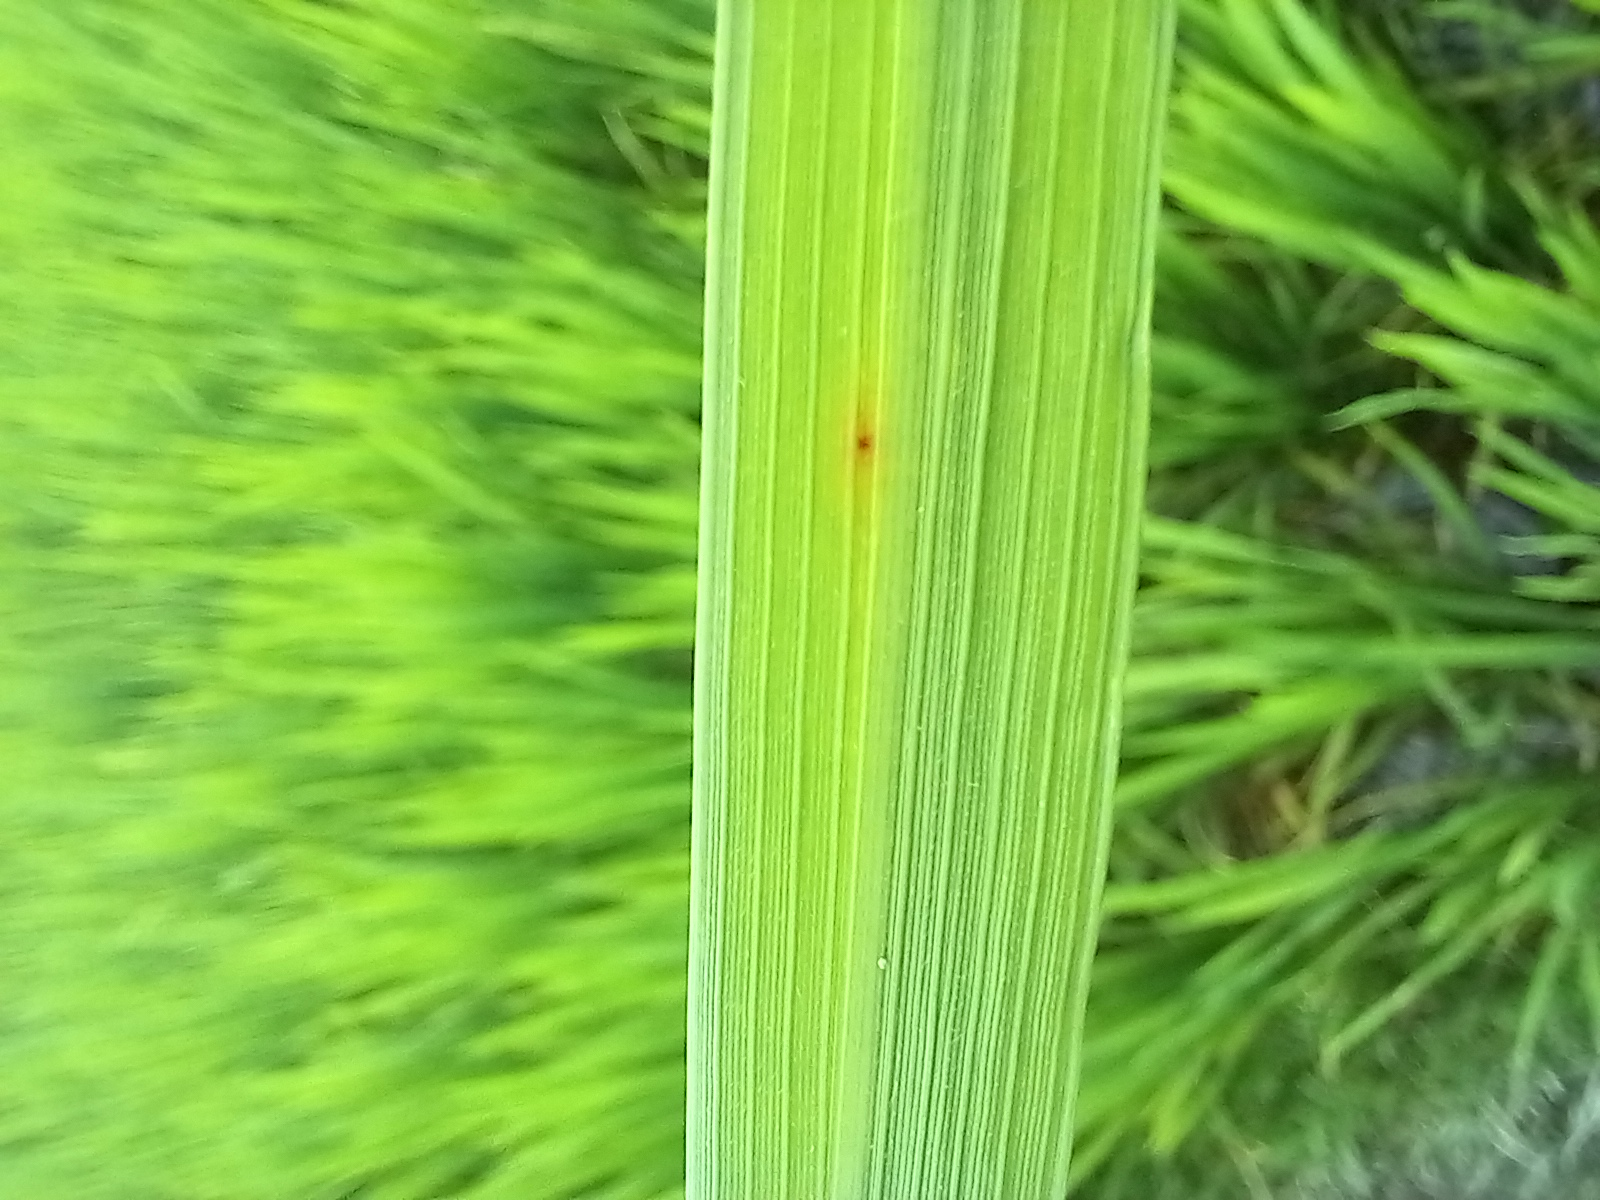

True: brown_spot; predicted: healthy

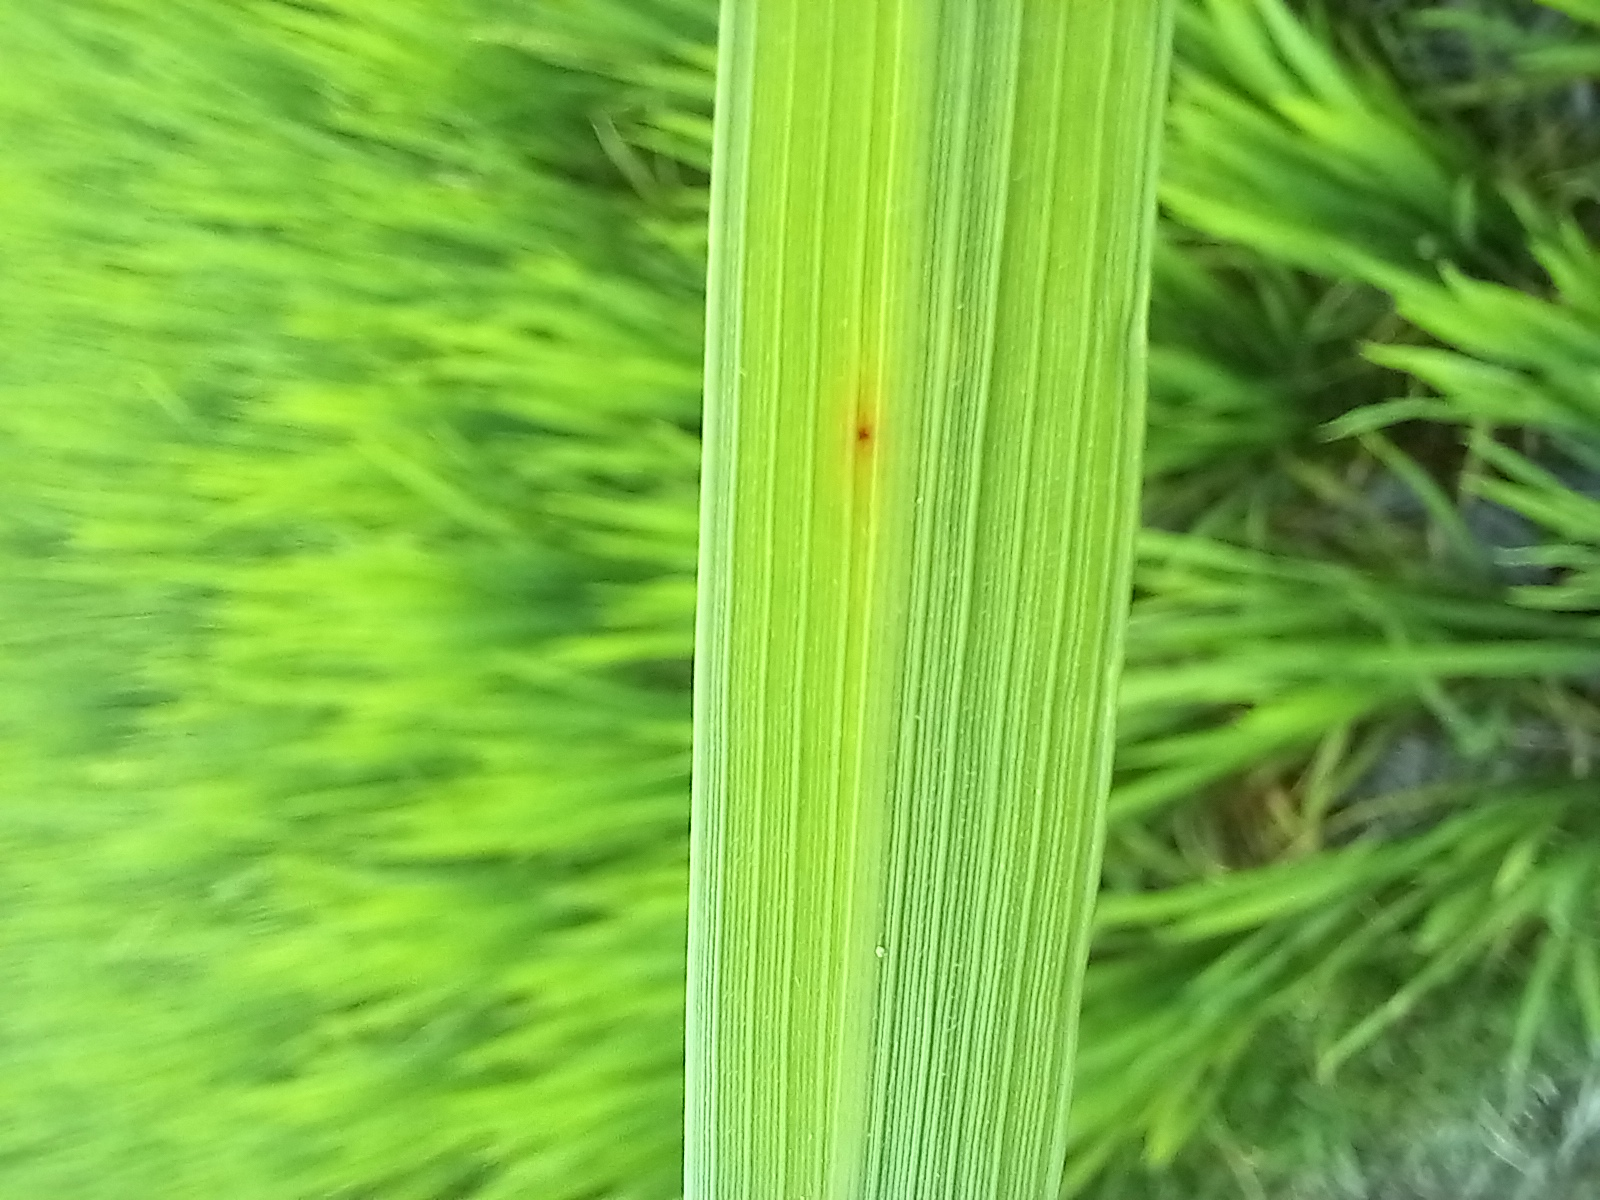

True: brown_spot; predicted: rice_blast

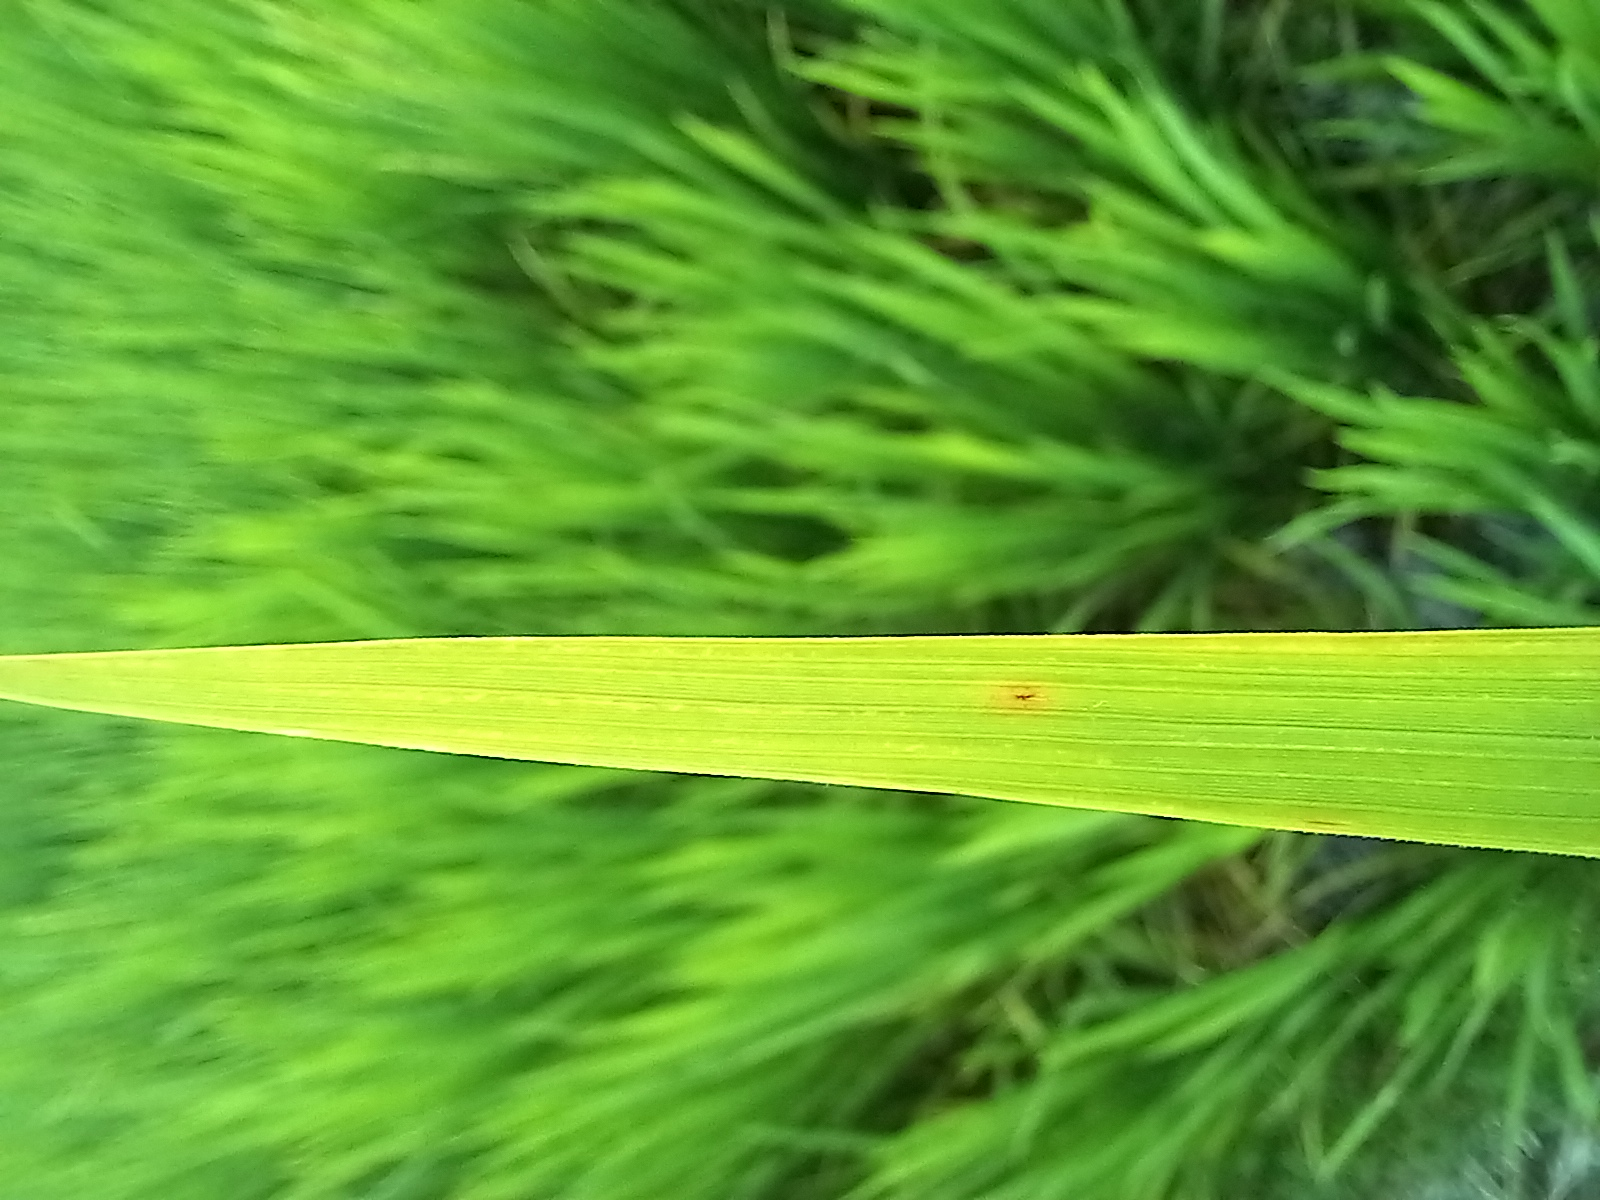

In [5]:
errors=pred[pred.label.ne(pred.predicted)]
display(errors.groupby(['label','predicted']).size().rename('images').reset_index())
for row in errors.head(3).itertuples():
    display(Markdown(f'True: {row.label}; predicted: {row.predicted}'))
    display(Image(filename=str(ROOT/row.path),width=220))

In [6]:
from rice_leaf_app.svm_inference import get_svm_predictor
model=get_svm_predictor()
for label in CLASSES:
    scores,preview,summary,rows=model.predict(EXAMPLES/f'{label}.jpg')
    display(Markdown(f'True: {CLASSES[label][0]}'))
    display(Markdown(summary))
    display(pd.DataFrame(rows,columns=['Class','Score (%)']))

True: Rice Blast

### SVM: Healthy Rice Leaf · ใบข้าวปกติ
คะแนนโมเดล **92.7%**

SVM baseline เลือกคลาสคะแนนสูงสุด ไม่มีเกณฑ์ไม่แน่ใจ; คะแนนไม่ใช่ความแน่นอนของโรค

,Class,Score (%)
0,Healthy Rice Leaf · ใบข้าวปกติ,92.68
1,Rice Blast · โรคไหม้,6.68
2,Brown Spot · โรคใบจุดสีน้ำตาล,0.52
3,Sheath Blight · โรคกาบใบแห้ง,0.09
4,Bacterial Leaf Blight · โรคขอบใบแห้ง,0.03


True: Bacterial Leaf Blight

### SVM: Bacterial Leaf Blight · โรคขอบใบแห้ง
คะแนนโมเดล **99.2%**

SVM baseline เลือกคลาสคะแนนสูงสุด ไม่มีเกณฑ์ไม่แน่ใจ; คะแนนไม่ใช่ความแน่นอนของโรค

...

### SVM: Healthy Rice Leaf · ใบข้าวปกติ
คะแนนโมเดล **44.5%**

SVM baseline เลือกคลาสคะแนนสูงสุด ไม่มีเกณฑ์ไม่แน่ใจ; คะแนนไม่ใช่ความแน่นอนของโรค

,Class,Score (%)
0,Healthy Rice Leaf · ใบข้าวปกติ,44.48
1,Brown Spot · โรคใบจุดสีน้ำตาล,37.91
2,Rice Blast · โรคไหม้,15.66
3,Sheath Blight · โรคกาบใบแห้ง,1.13
4,Bacterial Leaf Blight · โรคขอบใบแห้ง,0.82


True: Healthy Rice Leaf

### SVM: Healthy Rice Leaf · ใบข้าวปกติ
คะแนนโมเดล **92.4%**

SVM baseline เลือกคลาสคะแนนสูงสุด ไม่มีเกณฑ์ไม่แน่ใจ; คะแนนไม่ใช่ความแน่นอนของโรค

,Class,Score (%)
0,Healthy Rice Leaf · ใบข้าวปกติ,92.42
1,Rice Blast · โรคไหม้,7.42
2,Sheath Blight · โรคกาบใบแห้ง,0.08
3,Brown Spot · โรคใบจุดสีน้ำตาล,0.05
4,Bacterial Leaf Blight · โรคขอบใบแห้ง,0.03


## การนำไปใช้

Gradio app ใช้ไฟล์โมเดลที่บันทึกและ preprocessing เดียวกับตอนฝึก เลือก CNN หรือ SVM ในหน้า Classification แล้วดูผลเปรียบเทียบใน Evaluation เปิดเว็บจากลิงก์ README ได้โดยไม่ต้องเปิดเครื่องนักศึกษา ตรวจสถานะการเผยแพร่จริงที่ STATUS.md

ข้อมูลโมเดล/ผลรายคลาส/ข้อจำกัดและหลักฐานใน experiments/cnn5/RESULTS.md